<a href="https://colab.research.google.com/github/saurabh-parate/project-skytrax-airline/blob/main/group5-skytrax-airline-reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Understanding Passenger Satisfaction Through Advanced Text Mining

## A Comparative Analysis of Skytrax Airline Reviews

**Course:** IBM 6800 – Text Mining  
**Group:** Group 5  
**Dataset:** Skytrax Airline Reviews (Kaggle)

---

# 1. Introduction

The airline industry is one of the most competitive service industries, where customer satisfaction plays a critical role in influencing brand reputation, customer loyalty, and business performance. Passengers frequently share detailed online reviews describing their travel experiences, providing airlines with valuable feedback on service quality, operational performance, and overall customer experience.

These reviews contain rich unstructured textual information that cannot be fully analyzed using traditional statistical methods alone. Natural Language Processing (NLP) and text mining techniques enable organizations to automatically identify recurring topics, measure customer sentiment, and discover patterns hidden within large collections of customer feedback.

In this project, we analyze passenger reviews from the **Skytrax Airline Reviews** dataset using multiple text mining and machine learning techniques. The analysis includes exploratory data analysis, text preprocessing, topic modeling, sentiment analysis, and text classification to better understand the factors influencing passenger satisfaction and dissatisfaction.

The findings of this study provide practical insights into customer perceptions and demonstrate how advanced analytics can support data-driven decision-making in the airline industry.

---

# 2. Research Question

**How can advanced text mining and machine learning techniques identify the primary drivers of passenger satisfaction and dissatisfaction in airline reviews, and which analytical approaches provide the most accurate and interpretable results?**

---

# 3. Project Objectives

The objectives of this project are to:

- Identify the most frequently discussed topics in airline passenger reviews.
- Measure customer sentiment using multiple sentiment analysis techniques.
- Compare topic modeling algorithms to determine which produces the most meaningful and interpretable topics.
- Compare sentiment analysis models to identify the most effective approach for analyzing airline reviews.
- Develop a text classification model to predict whether a passenger recommends an airline based on review text.
- Generate practical recommendations that can help airlines improve customer satisfaction and service quality.

# 4. Import Libraries

This section imports the Python libraries required for data manipulation, visualization, and text processing. Additional libraries for topic modeling, sentiment analysis, and machine learning will be introduced in their respective sections to keep the notebook organized and easy to follow.

In [9]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import string

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Libraries imported successfully!")

Libraries imported successfully!


# 5. Data Loading

The Skytrax Airline Reviews dataset was obtained from Kaggle and contains passenger reviews collected from travelers across multiple airlines. The dataset includes both structured variables (e.g., airline, traveler type, cabin class, service ratings, and recommendation status) and unstructured textual reviews.

The combination of structured and unstructured data makes this dataset well suited for Natural Language Processing (NLP), sentiment analysis, topic modeling, and text classification.

In this section, the dataset is loaded into a Pandas DataFrame, and its dimensions are verified before further analysis.

In [10]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_excel("airline_reviews3.xlsx")

print("Dataset loaded successfully!\n")

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

Dataset loaded successfully!

Number of Rows    : 131,895
Number of Columns : 17


In [11]:
# Display the first five records

df.head()

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,"âœ… Trip Verified | London to Izmir via Istanbul. First time Iâ€™d flown TK. I found them very good in the air, cabin crew, planes, food, all very nice. Not so great on the ground, ground staff, call centre, computer systems. My flight from LHR was delayed so I missed the connection in Istanbul. Most ground staff donâ€™t speak English, and I was given contradictory instructions from those that could speak a little English. I eventually got on a flight to Izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. Also, Iâ€™d phoned a TK call centre (based in Ukraine) to pay an extra Â£40 or so each way for extra leg room seats. However, as the departure times kept changing, my seats kept changing, and for the return leg to London from Istanbul I was not given an extra leg room seat. Luckily there was a spare exit row seat and the cabin crew sorted me out. Overall, I think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with.",NaN,Business,Economy Class,London to Izmir via Istanbul,2019-05-01 00:00:00,4.0,5.0,4.0,4.0,2.0,4.0,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,"âœ… Trip Verified | Istanbul to Bucharest. We make our check in in the airport, they Take our luggage , we go to the gate and at the gate surprise they dont let uÈ™ board with two children, because they say the flight is overbooked. We had to wait in the airport with two children until 5 oclock in the morning until they bring uÈ™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. Our first and last flight with this airline.",NaN,Family Leisure,Economy Class,Istanbul to Bucharest,2019-05-01 00:00:00,4.0,1.0,1.0,1.0,1.0,1.0,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 6. Dataset Overview

Before performing any preprocessing or modeling, it is essential to understand the structure, quality, and characteristics of the dataset.

This section examines the dataset by reviewing its dimensions, variables, data types, missing values, duplicate records, and summary statistics. These analyses help identify potential data quality issues and guide the preprocessing steps required for subsequent text mining and machine learning tasks.

In [13]:
# Dataset Dimensions

print("="*60)
print("DATASET DIMENSIONS")
print("="*60)

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

DATASET DIMENSIONS
Number of Rows    : 131,895
Number of Columns : 17


In [14]:
# Display all column names

print("Dataset Variables\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Variables

1. airline
2. overall
3. author
4. review_date
5. customer_review
6. aircraft
7. traveller_type
8. cabin
9. route
10. date_flown
11. seat_comfort
12. cabin_service
13. food_bev
14. entertainment
15. ground_service
16. value_for_money
17. recommended


In [15]:
# Display data types

df.dtypes.to_frame(name="Data Type")

,Data Type
airline,object
overall,float64
author,object
review_date,object
customer_review,object
aircraft,object
traveller_type,object
cabin,object
route,object
date_flown,object


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131895 entries, 0 to 131894
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          65947 non-null  object 
 1   overall          64017 non-null  float64
 2   author           65947 non-null  object 
 3   review_date      65947 non-null  object 
 4   customer_review  65947 non-null  object 
 5   aircraft         19718 non-null  object 
 6   traveller_type   39755 non-null  object 
 7   cabin            63303 non-null  object 
 8   route            39726 non-null  object 
 9   date_flown       39633 non-null  object 
 10  seat_comfort     60681 non-null  float64
 11  cabin_service    60715 non-null  float64
 12  food_bev         52608 non-null  float64
 13  entertainment    44193 non-null  float64
 14  ground_service   39358 non-null  float64
 15  value_for_money  63975 non-null  float64
 16  recommended      64440 non-null  object 
dtypes: float64

In [17]:
df.head()

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,"âœ… Trip Verified | London to Izmir via Istanbul. First time Iâ€™d flown TK. I found them very good in the air, cabin crew, planes, food, all very nice. Not so great on the ground, ground staff, call centre, computer systems. My flight from LHR was delayed so I missed the connection in Istanbul. Most ground staff donâ€™t speak English, and I was given contradictory instructions from those that could speak a little English. I eventually got on a flight to Izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. Also, Iâ€™d phoned a TK call centre (based in Ukraine) to pay an extra Â£40 or so each way for extra leg room seats. However, as the departure times kept changing, my seats kept changing, and for the return leg to London from Istanbul I was not given an extra leg room seat. Luckily there was a spare exit row seat and the cabin crew sorted me out. Overall, I think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with.",NaN,Business,Economy Class,London to Izmir via Istanbul,2019-05-01 00:00:00,4.0,5.0,4.0,4.0,2.0,4.0,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,"âœ… Trip Verified | Istanbul to Bucharest. We make our check in in the airport, they Take our luggage , we go to the gate and at the gate surprise they dont let uÈ™ board with two children, because they say the flight is overbooked. We had to wait in the airport with two children until 5 oclock in the morning until they bring uÈ™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. Our first and last flight with this airline.",NaN,Family Leisure,Economy Class,Istanbul to Bucharest,2019-05-01 00:00:00,4.0,1.0,1.0,1.0,1.0,1.0,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6.6 Missing Values Analysis

Missing values are common in real-world datasets and can influence the quality of statistical analyses and machine learning models. Before preprocessing, it is important to identify variables containing missing values and determine the proportion of missing observations.

This analysis helps identify which variables require cleaning, imputation, or removal during the data preprocessing stage.

In [18]:
# ==========================================
# Missing Values Analysis
# ==========================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values.sort_values(
    by="Percentage (%)",
    ascending=False
)

missing_values

,Missing Values,Percentage (%)
aircraft,112177,85.05
ground_service,92537,70.16
date_flown,92262,69.95
route,92169,69.88
traveller_type,92140,69.86
entertainment,87702,66.49
food_bev,79287,60.11
seat_comfort,71214,53.99
cabin_service,71180,53.97
cabin,68592,52.01


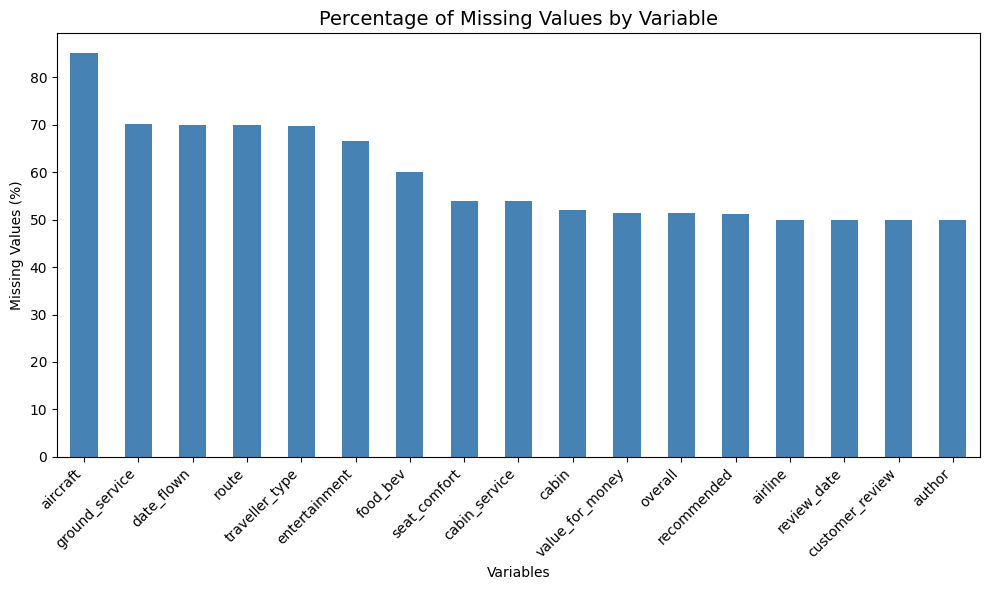

In [19]:
# Plot Missing Values

plt.figure(figsize=(10,6))

missing_values["Percentage (%)"].plot(
    kind="bar",
    color="steelblue"
)

plt.title("Percentage of Missing Values by Variable", fontsize=14)
plt.xlabel("Variables")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Interpretation

The missing-value analysis indicates that several variables contain incomplete observations. Variables such as aircraft type and in-flight entertainment are expected to exhibit higher proportions of missing values because they are not applicable to every passenger or flight. In contrast, the primary review text and recommendation variables contain relatively few missing observations, making them suitable for subsequent NLP and machine learning analyses.

These findings will guide the preprocessing strategy adopted in the data cleaning phase.

## 6.7 Duplicate Records Analysis

Duplicate observations can introduce bias into statistical analyses and machine learning models by overrepresenting certain passenger reviews. Therefore, identifying duplicate records is an important step before data preprocessing.

This section examines whether duplicate records exist within the dataset.

In [20]:
# ==========================================
# Duplicate Records Analysis
# ==========================================

duplicate_rows = df.duplicated().sum()

print("=" * 50)
print("DUPLICATE RECORDS")
print("=" * 50)

print(f"Number of Duplicate Rows : {duplicate_rows:,}")
print(f"Percentage of Dataset    : {(duplicate_rows / len(df) * 100):.2f}%")

DUPLICATE RECORDS
Number of Duplicate Rows : 70,711
Percentage of Dataset    : 53.61%
